In [ ]:
print("hello")

hello


In [2]:
!git clone https://github.com/WhoIsElijah233/speech-emotion-recognition.git

Cloning into 'speech-emotion-recognition'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 49 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 15.29 KiB | 15.29 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [3]:
%cd speech-emotion-recognition

/content/speech-emotion-recognition


In [4]:
%ls -l

total 12
drwxr-xr-x 2 root root 4096 Mar 22 01:36 notebooks/
-rw-r--r-- 1 root root  252 Mar 22 01:36 README.md
drwxr-xr-x 2 root root 4096 Mar 22 01:36 src/


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
import os

data_path = "/content/drive/MyDrive/emotion_dataset"
os.makedirs(data_path, exist_ok=True)

print("数据路径：", data_path)

数据路径： /content/drive/MyDrive/emotion_dataset


In [6]:
import torch
import os

fake_data_path = os.path.join(data_path, "fake_data")
os.makedirs(fake_data_path, exist_ok=True)

for i in range(100):
  waveform = torch.randn(1, 16000)
  label = torch.randint(0, 4, (1,))

  torch.save((waveform, label), f"{fake_data_path}/{i}.pt")

print("假数据生成完成")

假数据生成完成


In [13]:
path = "/content/drive/MyDrive/emotion_dataset/fake_data/0.pt"

import torch

data = torch.load(path)

print(type(data))
print(data)

<class 'tuple'>
(tensor([[-0.7730,  0.9142,  0.7770,  ...,  0.7458,  0.2562, -0.3265]]), tensor([1]))


In [22]:
# 编写好dataset文件后进行测试
%ls -l
from src.dataset import EmotionDataset

dataset = EmotionDataset(fake_data_path)

print(len(dataset))
print(dataset)
# waveform, label = torch.load(fake_data_path)
x, y = dataset[1]
print(x.shape)
print(y.shape)

total 12
drwxr-xr-x 2 root root 4096 Mar 22 01:36 notebooks/
-rw-r--r-- 1 root root  252 Mar 22 01:36 README.md
drwxr-xr-x 3 root root 4096 Mar 22 02:33 src/
100


NameError: name 'waveform' is not defined

In [24]:
import importlib
import src.dataset
importlib.reload(src.dataset)
from src.dataset import EmotionDataset

dataset = EmotionDataset()

print(len(dataset))

audio, label = dataset[0]

print(audio.shape)
print(label)

100
torch.Size([16000])
2


In [28]:
# 测试dataloader

from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=4, shuffle=True)

for audio, label in loader:
  print(audio.shape)
  print(label.shape)
  break

torch.Size([4, 16000])
torch.Size([4])


In [29]:
from src.model import EmotionModel

model = EmotionModel()

print(model)

EmotionModel(
  (fc1): Linear(in_features=16000, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)


In [30]:
x = torch.randn(4, 16000)

y = model(x)

print(y.shape)

torch.Size([4, 4])


In [32]:
!python src/train.py

epoch: 0
loss: 1.2997257709503174
loss: 1.3196630477905273
loss: 1.4462006092071533
loss: 1.2335944175720215
loss: 1.521924376487732
loss: 1.1883410215377808
loss: 1.370908260345459
loss: 1.609285593032837
loss: 1.766581416130066
loss: 1.6310031414031982
loss: 1.549546480178833
loss: 1.42839515209198
loss: 1.5639252662658691
loss: 0.9015762805938721
loss: 0.9968385696411133
loss: 1.8417346477508545
loss: 1.6688576936721802
loss: 1.8673653602600098
loss: 2.114471435546875
loss: 1.212471604347229
loss: 1.7353875637054443
loss: 2.379286050796509
loss: 2.5880305767059326
loss: 1.6525839567184448
loss: 1.799997091293335
epoch: 1
loss: 1.5647865533828735
loss: 1.4450067281723022
loss: 1.2374165058135986
loss: 0.9723362922668457
loss: 1.5359236001968384
loss: 1.4297242164611816
loss: 2.494507312774658
loss: 2.4934604167938232
loss: 1.420105218887329
loss: 1.304856300354004
loss: 1.3772668838500977
loss: 1.4019066095352173
loss: 1.1788711547851562
loss: 1.402359127998352
loss: 2.03135395050048

In [68]:
%ls -l

total 96
drwx------ 2 root root 4096 Mar 22  2018 Actor_01/
drwx------ 2 root root 4096 Mar 22  2018 Actor_02/
drwx------ 2 root root 4096 Mar 22  2018 Actor_03/
drwx------ 2 root root 4096 Mar 22  2018 Actor_04/
drwx------ 2 root root 4096 Mar 22  2018 Actor_05/
drwx------ 2 root root 4096 Mar 22  2018 Actor_06/
drwx------ 2 root root 4096 Mar 22  2018 Actor_07/
drwx------ 2 root root 4096 Mar 22  2018 Actor_08/
drwx------ 2 root root 4096 Mar 22  2018 Actor_09/
drwx------ 2 root root 4096 Mar 22  2018 Actor_10/
drwx------ 2 root root 4096 Mar 22  2018 Actor_11/
drwx------ 2 root root 4096 Mar 22 03:21 Actor_12/
drwx------ 2 root root 4096 Mar 22 03:21 Actor_13/
drwx------ 2 root root 4096 Mar 22 03:21 Actor_14/
drwx------ 2 root root 4096 Mar 22  2018 Actor_15/
drwx------ 2 root root 4096 Mar 22  2018 Actor_16/
drwx------ 2 root root 4096 Mar 22  2018 Actor_17/
drwx------ 2 root root 4096 Mar 22  2018 Actor_18/
drwx------ 2 root root 4096 Mar 22  2018 Actor_19/
drwx------ 2 root root

In [69]:
%cd ..
%ls -l

/content/drive/MyDrive/emotion_dataset
total 8
drwx------  2 root root 4096 Mar 22 01:41 fake_data/
drwx------ 26 root root 4096 Mar 22 03:22 RAVDESS/


torch.Size([1, 158558])
48000
torch.Size([1, 80, 793])


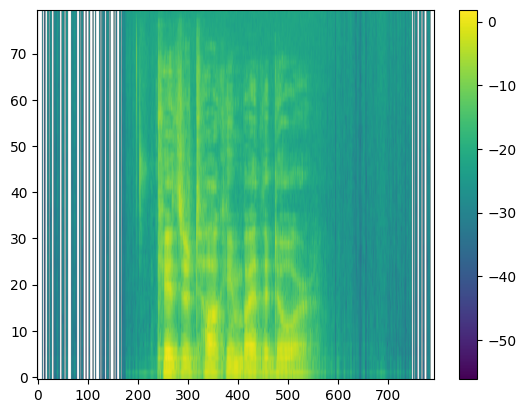

In [72]:
import torchaudio
import os

root = "RAVDESS"

actor = os.listdir(root)[0]

path = os.path.join(root, actor, os.listdir(os.path.join(root, actor))[0])

waveform, sr = torchaudio.load(path)

print(waveform.shape)
print(sr)

import torchaudio.transforms as T

mel = T.MelSpectrogram(
    sample_rate=16000,
    n_mels=80
)

spec = mel(waveform)

print(spec.shape)

import matplotlib.pyplot as plt

plt.imshow(spec[0].log2().numpy(), aspect="auto", origin="lower")
plt.colorbar()
plt.show()

In [73]:
%pwd

'/content/drive/MyDrive/emotion_dataset'

In [74]:
%cd /content/speech-emotion-recognition/src

/content/speech-emotion-recognition/src


In [77]:
import importlib
import dataset
importlib.reload(dataset)
from dataset import EmotionDataset

dataset = EmotionDataset()

print("dataset size:", len(dataset))

x, y = dataset[0]

print("spectrogram shape:", x.shape)
print("label:", y)

dataset size: 1440
spectrogram shape: torch.Size([1, 80, 300])
label: 0


In [78]:
from model import EmotionCNN
import torch

model = EmotionCNN()

x = torch.randn(4, 1, 80, 300)

y = model(x)

print(y.shape)

torch.Size([4, 8])


In [79]:
!python train.py

epoch: 0 loss: 2.32343334224489
epoch: 1 loss: 1.6804325037532382
